In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = '/content/drive/MyDrive/HR_GenAI_Research'
print(os.listdir(path))

['Task Statements.xlsx', 'Skills.xlsx', 'Occupation Data.xlsx', 'Work Activities.xlsx', 'HR_GenAI_Exposure_Results.xlsx', 'HR_Tasks_Scored.xlsx']


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/HR_GenAI_Research'

tasks = pd.read_excel(f'{path}/Task Statements.xlsx')
skills = pd.read_excel(f'{path}/Skills.xlsx')
activities = pd.read_excel(f'{path}/Work Activities.xlsx')
occupations = pd.read_excel(f'{path}/Occupation Data.xlsx')

print("✅ Tasks:", tasks.shape)
print("✅ Skills:", skills.shape)
print("✅ Activities:", activities.shape)
print("✅ Occupations:", occupations.shape)

✅ Tasks: (18796, 8)
✅ Skills: (62580, 15)
✅ Activities: (73308, 15)
✅ Occupations: (1016, 3)


In [ ]:
# Define HR-related SOC codes
hr_soc_codes = [
    '11-3121.00',  # Human Resources Managers
    '13-1071.00',  # Human Resources Specialists
    '13-1141.00',  # Compensation & Benefits Analysts
    '13-1151.00',  # Training & Development Specialists
    '11-3131.00',  # Training & Development Managers
    '43-4161.00',  # Human Resources Assistants
    '13-1071.01',  # Job Analysis Specialists
    '13-1141.01',  # Compensation Analysts
    '13-1151.00',  # Training & Development Specialists
    '11-9033.00',  # Education Administrators
    '13-1072.00',  # Compensation & Benefits Managers
    '13-1075.00',  # Labor Relations Specialists
]

# Filter occupations to HR only
hr_occupations = occupations[occupations['O*NET-SOC Code'].isin(hr_soc_codes)]
print("HR Occupations found:", len(hr_occupations))
print()
print(hr_occupations[['O*NET-SOC Code', 'Title']].to_string(index=False))

HR Occupations found: 8

O*NET-SOC Code                                                      Title
    11-3121.00                                   Human Resources Managers
    11-3131.00                          Training and Development Managers
    11-9033.00                    Education Administrators, Postsecondary
    13-1071.00                                Human Resources Specialists
    13-1075.00                                Labor Relations Specialists
    13-1141.00       Compensation, Benefits, and Job Analysis Specialists
    13-1151.00                       Training and Development Specialists
    43-4161.00 Human Resources Assistants, Except Payroll and Timekeeping


In [ ]:
# Filter tasks to HR occupations only
hr_tasks = tasks[tasks['O*NET-SOC Code'].isin(hr_soc_codes)].copy()
print(f"Total HR tasks found: {len(hr_tasks)}")
print(hr_tasks.columns.tolist())

Total HR tasks found: 180
['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']


In [ ]:

# GEN AI EXPOSURE SCORING ENGINE
# ============================================

# Step 1: Define keywords for each exposure level
high_exposure_keywords = [
    'schedule', 'process', 'maintain', 'record', 'track',
    'calculate', 'screen', 'generate', 'prepare', 'compile',
    'update', 'enter', 'file', 'organize', 'administer',
    'coordinate', 'monitor', 'document', 'review', 'verify',
    'collect', 'input', 'sort', 'distribute', 'notify'
]

medium_exposure_keywords = [
    'assist', 'support', 'implement', 'conduct', 'evaluate',
    'analyze', 'assess', 'identify', 'develop', 'recommend',
    'communicate', 'provide', 'ensure', 'facilitate', 'manage'
]

low_exposure_keywords = [
    'counsel', 'advise', 'negotiate', 'mediate', 'coach',
    'mentor', 'lead', 'influence', 'resolve', 'judge',
    'strategize', 'inspire', 'empathize', 'decide', 'build',
    'relate', 'advocate', 'collaborate', 'partner', 'consult'
]

# Step 2: Scoring function for each task
def score_task(task_text):
    task_lower = str(task_text).lower()

    for keyword in low_exposure_keywords:
        if keyword in task_lower:
            return 1  # Low AI exposure — human judgment needed

    for keyword in high_exposure_keywords:
        if keyword in task_lower:
            return 5  # High AI exposure — easily automated

    for keyword in medium_exposure_keywords:
        if keyword in task_lower:
            return 3  # Medium AI exposure — AI can assist

    return 3  # Default to medium if no keywords match

# Step 3: Apply scoring to every HR task
hr_tasks['AI_Exposure_Score'] = hr_tasks['Task'].apply(score_task)

# Step 4: Show score distribution
print("Score Distribution:")
print(hr_tasks['AI_Exposure_Score'].value_counts().sort_index())
print()

# Step 5: Show sample tasks with their scores
print("Sample scored tasks:")
print(hr_tasks[['Title', 'Task', 'AI_Exposure_Score']].head(15).to_string(index=False))


Score Distribution:
AI_Exposure_Score
1    33
3    78
5    69
Name: count, dtype: int64

Sample scored tasks:
                   Title                                                                                                                                                                                        Task  AI_Exposure_Score
Human Resources Managers                                 Serve as a link between management and employees by handling questions, interpreting and administering contracts and helping resolve work-related problems.                  1
Human Resources Managers                            Plan, direct, supervise, and coordinate work activities of subordinates and staff relating to employment, compensation, labor relations, and employee relations.                  5
Human Resources Managers                                  Perform difficult staffing duties, including dealing with understaffing, refereeing disputes, firing employees, and administering discip

In [ ]:
# ── RANK OCCUPATIONS BY AI EXPOSURE SCORE ─────────────────────────────────────
occupation_scores = hr_tasks.groupby('Title')['AI_Exposure_Score'].agg(
    Average_AI_Exposure='mean',
    Total_Tasks='count',
    High_Exposure_Tasks=lambda x: (x == 5).sum(),
    Low_Exposure_Tasks=lambda x: (x == 1).sum()
).reset_index()

occupation_scores = occupation_scores.sort_values(
    'Average_AI_Exposure', ascending=False
).reset_index(drop=True)

def exposure_label(score):
    if score >= 3.5:
        return 'High Exposure'
    elif score >= 2.5:
        return 'Moderate Exposure'
    else:
        return 'Low Exposure'

occupation_scores['Exposure_Level'] = occupation_scores[
    'Average_AI_Exposure'].apply(exposure_label)

print("=" * 65)
print("   HR OCCUPATIONS RANKED BY GEN AI EXPOSURE")
print("=" * 65)
for i, row in occupation_scores.iterrows():
    print(f"\n#{i+1} {row['Title']}")
    print(f"    AI Exposure Score    : {row['Average_AI_Exposure']:.2f} / 5.0")
    print(f"    Exposure Level       : {row['Exposure_Level']}")
    print(f"    High Exposure Tasks  : {row['High_Exposure_Tasks']} of {row['Total_Tasks']}")
    print(f"    Low Exposure Tasks   : {row['Low_Exposure_Tasks']} of {row['Total_Tasks']}")

   HR OCCUPATIONS RANKED BY GEN AI EXPOSURE

#1 Human Resources Assistants, Except Payroll and Timekeeping
    AI Exposure Score    : 3.95 / 5.0
    Exposure Level       : High Exposure
    High Exposure Tasks  : 11 of 19
    Low Exposure Tasks   : 2 of 19

#2 Training and Development Managers
    AI Exposure Score    : 3.83 / 5.0
    Exposure Level       : High Exposure
    High Exposure Tasks  : 5 of 12
    Low Exposure Tasks   : 0 of 12

#3 Training and Development Specialists
    AI Exposure Score    : 3.50 / 5.0
    Exposure Level       : High Exposure
    High Exposure Tasks  : 8 of 20
    Low Exposure Tasks   : 3 of 20

#4 Compensation, Benefits, and Job Analysis Specialists
    AI Exposure Score    : 3.45 / 5.0
    Exposure Level       : Moderate Exposure
    High Exposure Tasks  : 9 of 22
    Low Exposure Tasks   : 4 of 22

#5 Human Resources Specialists
    AI Exposure Score    : 3.31 / 5.0
    Exposure Level       : Moderate Exposure
    High Exposure Tasks  : 9 of 26
    Lo

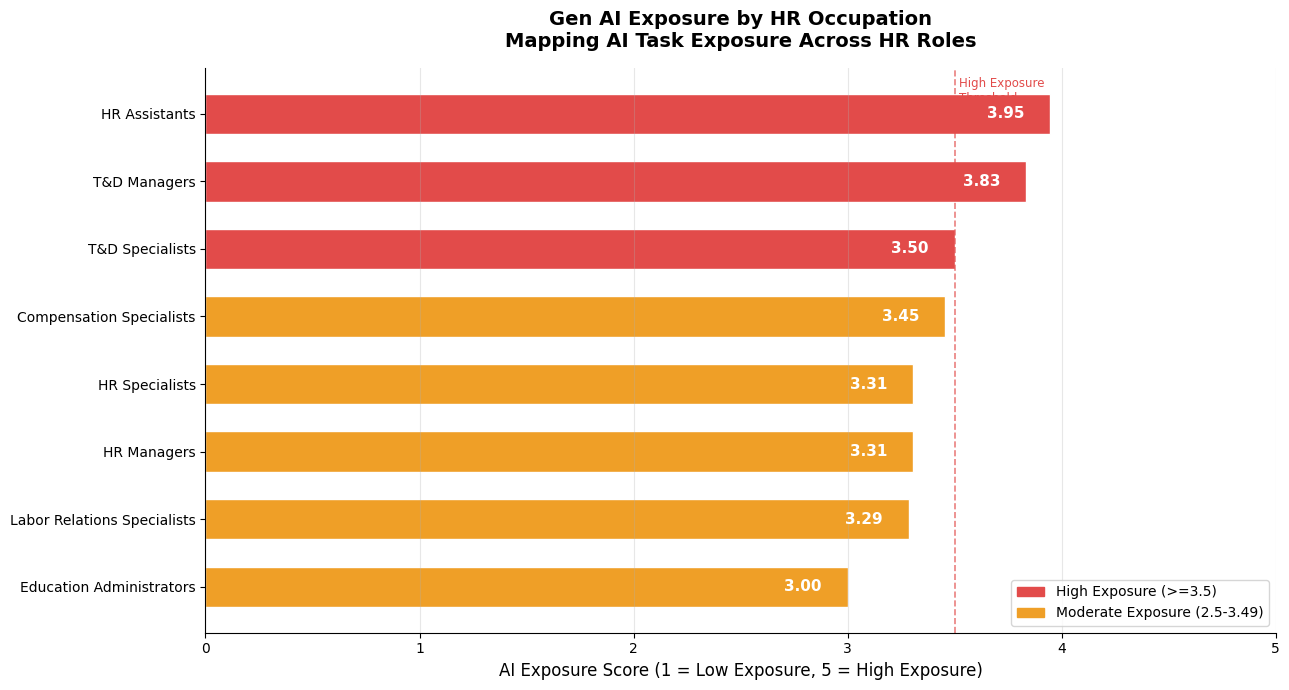

✅ Figure 1 saved!


In [ ]:
# ── FIGURE 1 ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

short_names = {
    'Human Resources Assistants, Except Payroll and Timekeeping': 'HR Assistants',
    'Training and Development Managers': 'T&D Managers',
    'Training and Development Specialists': 'T&D Specialists',
    'Compensation, Benefits, and Job Analysis Specialists': 'Compensation Specialists',
    'Human Resources Specialists': 'HR Specialists',
    'Human Resources Managers': 'HR Managers',
    'Labor Relations Specialists': 'Labor Relations Specialists',
    'Education Administrators, Postsecondary': 'Education Administrators'
}

occupation_scores['Short_Name'] = occupation_scores['Title'].map(short_names)

colors = []
for score in occupation_scores['Average_AI_Exposure']:
    if score >= 3.5:
        colors.append('#E24B4A')
    elif score >= 2.5:
        colors.append('#EF9F27')
    else:
        colors.append('#639922')

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    occupation_scores['Short_Name'][::-1],
    occupation_scores['Average_AI_Exposure'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

# Labels inside bars
for bar, score in zip(bars, occupation_scores['Average_AI_Exposure'][::-1]):
    ax.text(
        bar.get_width() - 0.12,
        bar.get_y() + bar.get_height()/2,
        f'{score:.2f}',
        va='center', ha='right',
        fontsize=11, fontweight='bold', color='white'
    )

# Threshold line
ax.axvline(x=3.5, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(3.52, 7.55, 'High Exposure\nThreshold', color='#E24B4A', fontsize=8.5, va='top')

ax.set_xlim(0, 5.0)
ax.set_xlabel('AI Exposure Score (1 = Low Exposure, 5 = High Exposure)', fontsize=12)
ax.set_title(
    'Gen AI Exposure by HR Occupation\nMapping AI Task Exposure Across HR Roles',
    fontsize=14, fontweight='bold', pad=15
)

red_patch   = mpatches.Patch(color='#E24B4A', label='High Exposure (>=3.5)')
amber_patch = mpatches.Patch(color='#EF9F27', label='Moderate Exposure (2.5-3.49)')
ax.legend(handles=[red_patch, amber_patch], loc='lower right', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure1_AI_Exposure_by_HR_Role.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved!")

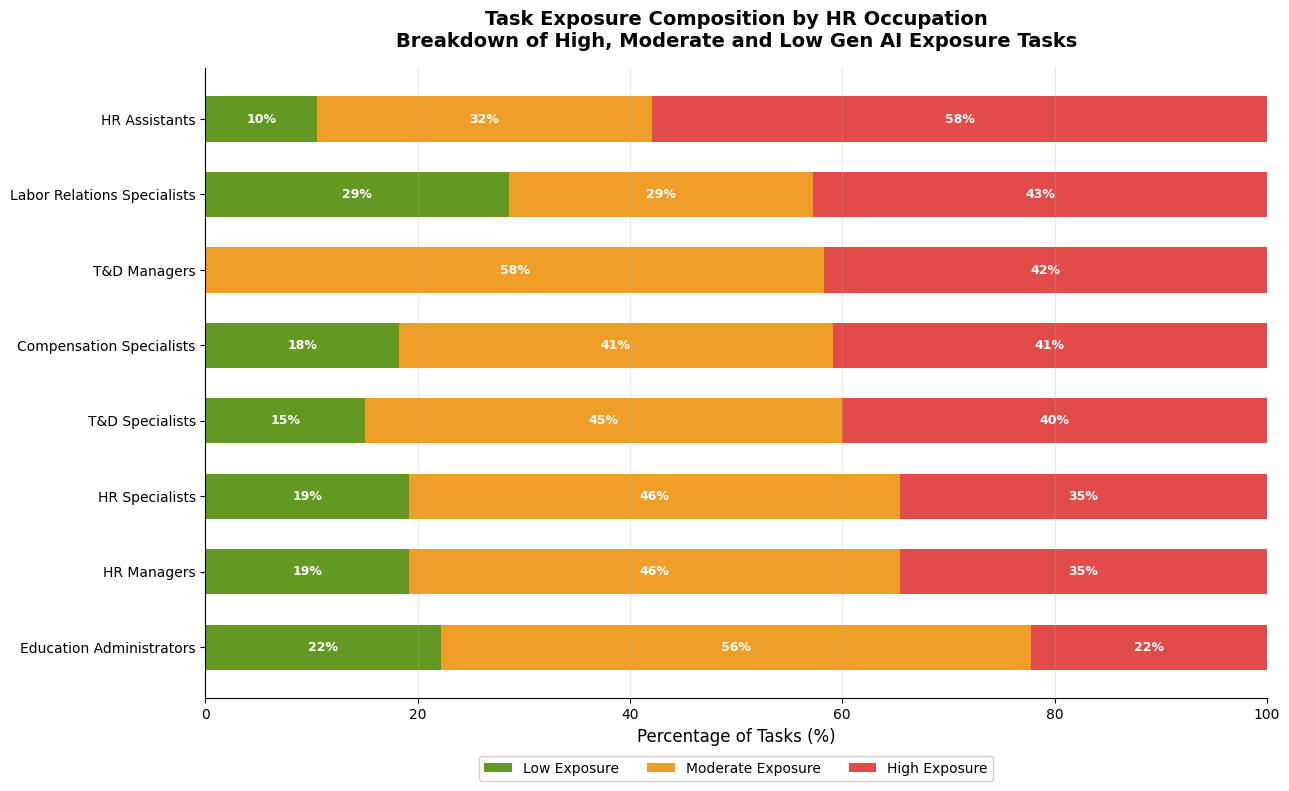

Figure 2 saved!


In [ ]:
# ── FIGURE 2 ──────────────────────────────────────────────────────────────────
breakdown = hr_tasks.groupby(['Title', 'AI_Exposure_Score']).size().unstack(fill_value=0)
breakdown.columns = ['Low Exposure', 'Moderate Exposure', 'High Exposure']
breakdown['Total'] = breakdown.sum(axis=1)
breakdown['% High Exposure'] = (breakdown['High Exposure'] / breakdown['Total'] * 100).round(1)
breakdown['% Moderate Exposure'] = (breakdown['Moderate Exposure'] / breakdown['Total'] * 100).round(1)
breakdown['% Low Exposure'] = (breakdown['Low Exposure'] / breakdown['Total'] * 100).round(1)
breakdown.index = breakdown.index.map(short_names)
breakdown = breakdown.sort_values('% High Exposure', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(breakdown.index, breakdown['% Low Exposure'], color='#639922', label='Low Exposure', height=0.6)
ax.barh(breakdown.index, breakdown['% Moderate Exposure'], color='#EF9F27', label='Moderate Exposure', height=0.6, left=breakdown['% Low Exposure'])
ax.barh(breakdown.index, breakdown['% High Exposure'], color='#E24B4A', label='High Exposure', height=0.6, left=breakdown['% Low Exposure'] + breakdown['% Moderate Exposure'])

for i, (l, m, h) in enumerate(zip(breakdown['% Low Exposure'], breakdown['% Moderate Exposure'], breakdown['% High Exposure'])):
    if l > 7:
        ax.text(l/2, i, f'{l:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if m > 7:
        ax.text(l + m/2, i, f'{m:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if h > 7:
        ax.text(l + m + h/2, i, f'{h:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Percentage of Tasks (%)', fontsize=12)
ax.set_title(
    'Task Exposure Composition by HR Occupation\nBreakdown of High, Moderate and Low Gen AI Exposure Tasks',
    fontsize=14, fontweight='bold', pad=15
)

# Legend placed completely outside the chart — below the x axis, never overlaps
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=10,
    framealpha=0.9
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure2_Task_Breakdown_by_Role.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved!")

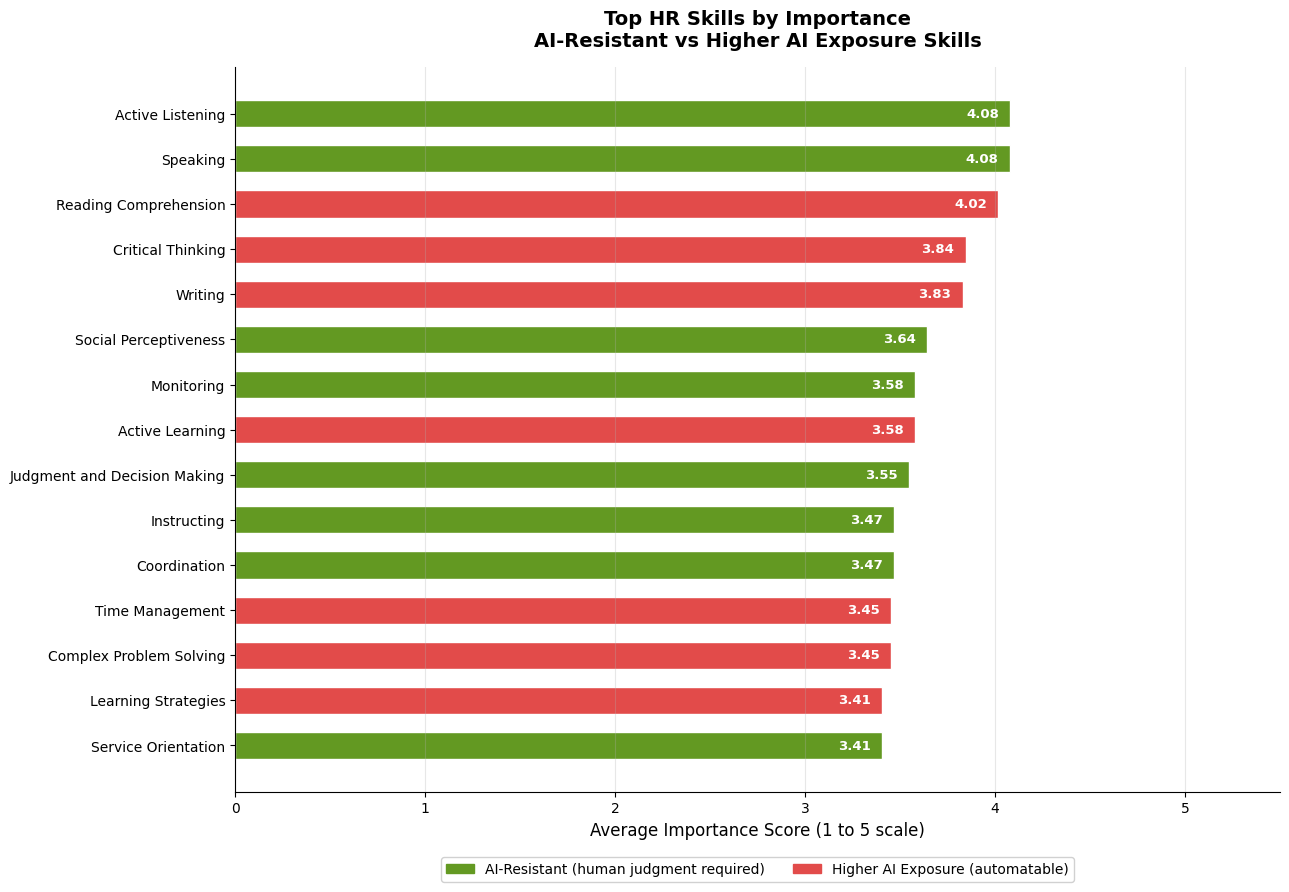

Figure 3 saved!


In [ ]:
# ── FIGURE 3 ──────────────────────────────────────────────────────────────────
hr_skills = skills[skills['O*NET-SOC Code'].isin(hr_soc_codes)].copy()
hr_skills_imp = hr_skills[hr_skills['Scale ID'] == 'IM']

top_skills = hr_skills_imp.groupby('Element Name')['Data Value'].mean().reset_index()
top_skills.columns = ['Skill', 'Avg_Importance']
top_skills = top_skills.sort_values('Avg_Importance', ascending=False).head(15)

ai_resistant = [
    'Social Perceptiveness', 'Negotiation', 'Persuasion',
    'Instructing', 'Service Orientation', 'Coordination',
    'Judgment and Decision Making', 'Active Listening',
    'Speaking', 'Monitoring'
]

top_skills['Color'] = top_skills['Skill'].apply(
    lambda x: '#639922' if x in ai_resistant else '#E24B4A'
)
top_skills = top_skills.sort_values('Avg_Importance', ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(top_skills['Skill'], top_skills['Avg_Importance'],
               color=top_skills['Color'], edgecolor='white', height=0.6)

for bar, val in zip(bars, top_skills['Avg_Importance']):
    ax.text(
        bar.get_width() - 0.06,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center', ha='right',
        fontsize=9.5, fontweight='bold', color='white'
    )

ax.set_xlim(0, 5.5)
ax.set_xlabel('Average Importance Score (1 to 5 scale)', fontsize=12)
ax.set_title(
    'Top HR Skills by Importance\nAI-Resistant vs Higher AI Exposure Skills',
    fontsize=14, fontweight='bold', pad=15
)

g_patch = mpatches.Patch(color='#639922', label='AI-Resistant (human judgment required)')
r_patch = mpatches.Patch(color='#E24B4A', label='Higher AI Exposure (automatable)')

# Legend placed completely outside the chart — below the x axis, never overlaps
ax.legend(
    handles=[g_patch, r_patch],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=10,
    framealpha=0.9
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure3_Surviving_Skills.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 saved!")



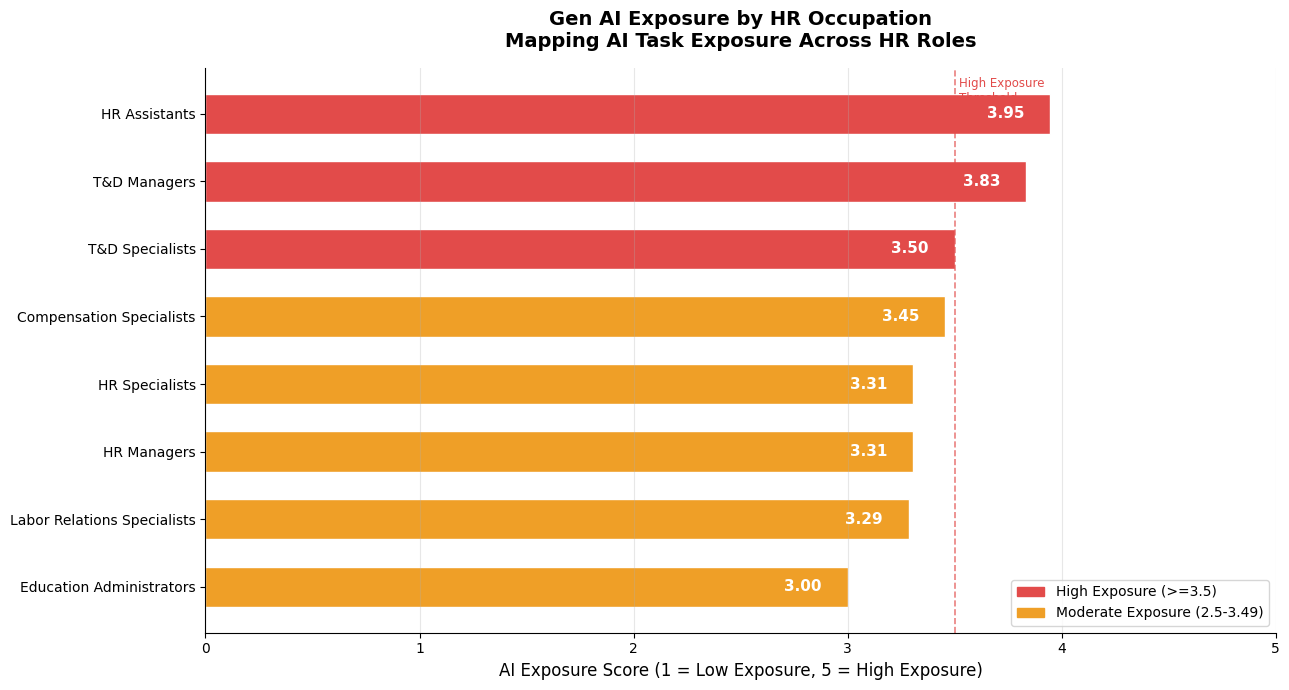

Figure 1 saved!


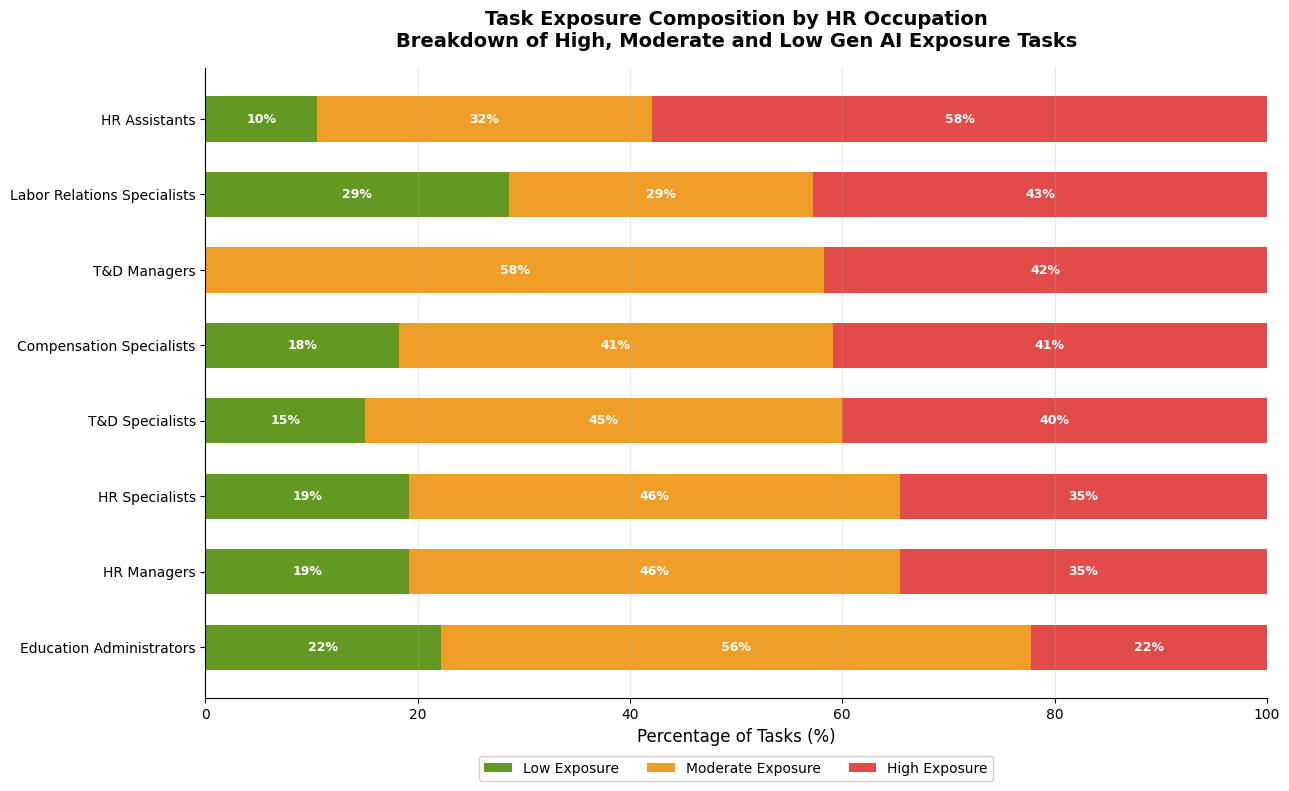

Figure 2 saved!


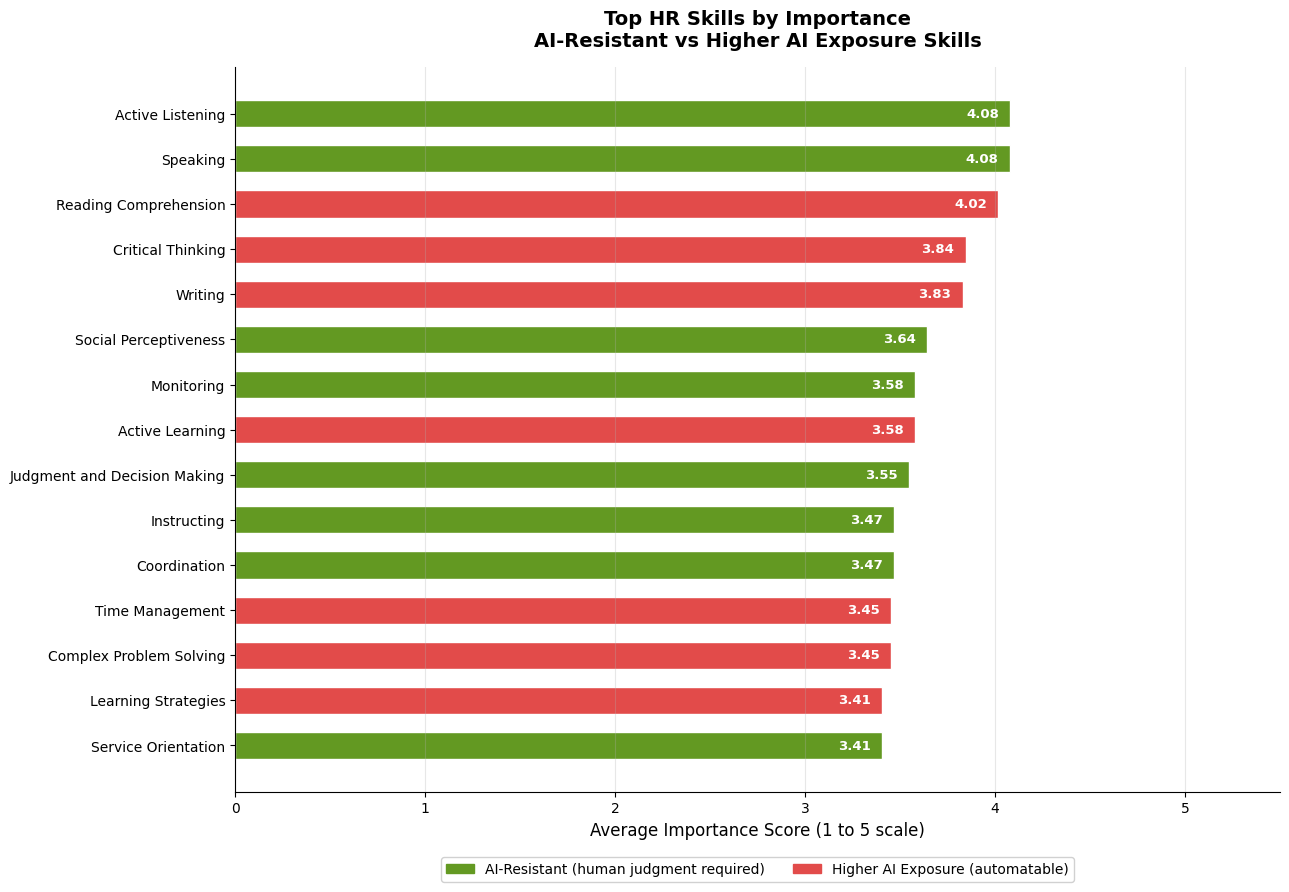

Figure 3 saved!
All files saved to Google Drive!
Figure1_AI_Exposure_by_HR_Role.png
Figure2_Task_Breakdown_by_Role.png
Figure3_Surviving_Skills.png
HR_GenAI_Exposure_Results.xlsx
HR_Tasks_Scored.xlsx


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

short_names = {
    'Human Resources Assistants, Except Payroll and Timekeeping': 'HR Assistants',
    'Training and Development Managers': 'T&D Managers',
    'Training and Development Specialists': 'T&D Specialists',
    'Compensation, Benefits, and Job Analysis Specialists': 'Compensation Specialists',
    'Human Resources Specialists': 'HR Specialists',
    'Human Resources Managers': 'HR Managers',
    'Labor Relations Specialists': 'Labor Relations Specialists',
    'Education Administrators, Postsecondary': 'Education Administrators'
}

occupation_scores['Short_Name'] = occupation_scores['Title'].map(short_names)

colors = []
for score in occupation_scores['Average_AI_Exposure']:
    if score >= 3.5:
        colors.append('#E24B4A')
    elif score >= 2.5:
        colors.append('#EF9F27')
    else:
        colors.append('#639922')

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    occupation_scores['Short_Name'][::-1],
    occupation_scores['Average_AI_Exposure'][::-1],
    color=colors[::-1], edgecolor='white', height=0.6
)
for bar, score in zip(bars, occupation_scores['Average_AI_Exposure'][::-1]):
    ax.text(bar.get_width() - 0.12, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', ha='right',
            fontsize=11, fontweight='bold', color='white')
ax.axvline(x=3.5, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(3.52, 7.55, 'High Exposure\nThreshold', color='#E24B4A', fontsize=8.5, va='top')
ax.set_xlim(0, 5.0)
ax.set_xlabel('AI Exposure Score (1 = Low Exposure, 5 = High Exposure)', fontsize=12)
ax.set_title('Gen AI Exposure by HR Occupation\nMapping AI Task Exposure Across HR Roles',
             fontsize=14, fontweight='bold', pad=15)
red_patch   = mpatches.Patch(color='#E24B4A', label='High Exposure (>=3.5)')
amber_patch = mpatches.Patch(color='#EF9F27', label='Moderate Exposure (2.5-3.49)')
ax.legend(handles=[red_patch, amber_patch], loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure1_AI_Exposure_by_HR_Role.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 1 saved!")

breakdown = hr_tasks.groupby(['Title', 'AI_Exposure_Score']).size().unstack(fill_value=0)
breakdown.columns = ['Low Exposure', 'Moderate Exposure', 'High Exposure']
breakdown['Total'] = breakdown.sum(axis=1)
breakdown['% High Exposure'] = (breakdown['High Exposure'] / breakdown['Total'] * 100).round(1)
breakdown['% Moderate Exposure'] = (breakdown['Moderate Exposure'] / breakdown['Total'] * 100).round(1)
breakdown['% Low Exposure'] = (breakdown['Low Exposure'] / breakdown['Total'] * 100).round(1)
breakdown.index = breakdown.index.map(short_names)
breakdown = breakdown.sort_values('% High Exposure', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(breakdown.index, breakdown['% Low Exposure'], color='#639922', label='Low Exposure', height=0.6)
ax.barh(breakdown.index, breakdown['% Moderate Exposure'], color='#EF9F27', label='Moderate Exposure', height=0.6, left=breakdown['% Low Exposure'])
ax.barh(breakdown.index, breakdown['% High Exposure'], color='#E24B4A', label='High Exposure', height=0.6, left=breakdown['% Low Exposure'] + breakdown['% Moderate Exposure'])
for i, (l, m, h) in enumerate(zip(breakdown['% Low Exposure'], breakdown['% Moderate Exposure'], breakdown['% High Exposure'])):
    if l > 7:
        ax.text(l/2, i, f'{l:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if m > 7:
        ax.text(l + m/2, i, f'{m:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if h > 7:
        ax.text(l + m + h/2, i, f'{h:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage of Tasks (%)', fontsize=12)
ax.set_title('Task Exposure Composition by HR Occupation\nBreakdown of High, Moderate and Low Gen AI Exposure Tasks',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure2_Task_Breakdown_by_Role.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved!")

hr_skills = skills[skills['O*NET-SOC Code'].isin(hr_soc_codes)].copy()
hr_skills_imp = hr_skills[hr_skills['Scale ID'] == 'IM']
top_skills = hr_skills_imp.groupby('Element Name')['Data Value'].mean().reset_index()
top_skills.columns = ['Skill', 'Avg_Importance']
top_skills = top_skills.sort_values('Avg_Importance', ascending=False).head(15)
ai_resistant = ['Social Perceptiveness', 'Negotiation', 'Persuasion',
                'Instructing', 'Service Orientation', 'Coordination',
                'Judgment and Decision Making', 'Active Listening', 'Speaking', 'Monitoring']
top_skills['Color'] = top_skills['Skill'].apply(lambda x: '#639922' if x in ai_resistant else '#E24B4A')
top_skills = top_skills.sort_values('Avg_Importance', ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(top_skills['Skill'], top_skills['Avg_Importance'],
               color=top_skills['Color'], edgecolor='white', height=0.6)
for bar, val in zip(bars, top_skills['Avg_Importance']):
    ax.text(bar.get_width() - 0.06, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='right',
            fontsize=9.5, fontweight='bold', color='white')
ax.set_xlim(0, 5.5)
ax.set_xlabel('Average Importance Score (1 to 5 scale)', fontsize=12)
ax.set_title('Top HR Skills by Importance\nAI-Resistant vs Higher AI Exposure Skills',
             fontsize=14, fontweight='bold', pad=15)
g_patch = mpatches.Patch(color='#639922', label='AI-Resistant (human judgment required)')
r_patch = mpatches.Patch(color='#E24B4A', label='Higher AI Exposure (automatable)')
ax.legend(handles=[g_patch, r_patch], loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{path}/Figure3_Surviving_Skills.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 saved!")

occupation_scores.to_excel(f'{path}/HR_GenAI_Exposure_Results.xlsx', index=False)
hr_tasks[['O*NET-SOC Code', 'Title', 'Task', 'Task Type', 'AI_Exposure_Score']].to_excel(
    f'{path}/HR_Tasks_Scored.xlsx', index=False)

print("All files saved to Google Drive!")
print("Figure1_AI_Exposure_by_HR_Role.png")
print("Figure2_Task_Breakdown_by_Role.png")
print("Figure3_Surviving_Skills.png")
print("HR_GenAI_Exposure_Results.xlsx")
print("HR_Tasks_Scored.xlsx")